In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Clustering_project_dataset.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [4]:
#handling missing values
df["Income"] = df["Income"].fillna(df["Income"].median())
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [5]:
#feature engineering
#Age
df["Age"] = 2026 - df["Year_Birth"]
df = df.drop("Year_Birth", axis=1)

In [6]:
#Customer Tenure
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
ref = df["Dt_Customer"].max()
df["Customer_tenure_days"] = (ref - df["Dt_Customer"]).dt.days
df = df.drop("Dt_Customer", axis=1)

In [7]:
#Total Spending Amount
df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
df = df.drop(columns = [ 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'])


In [8]:
#total children
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]
df = df.drop(columns = [ 'Kidhome', 'Teenhome'])

In [9]:
# Encoding categorical columns
df["Education"].value_counts()
df["Education"] = df["Education"].replace({
    "Graduation":"Graduate",
    "Basic": "Under_Graduate",
    "2n Cycle" :  "Under_Graduate",
    "PhD" : "Post_Graduate",
    "Master" : "Post_Graduate"
})


In [10]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married" : "1",
    "Together": "1",
    "Single" :"0",
    "Divorced" : "0",
    "Widow" : "0",
    "Alone": "0",
    "Absurd": "0",
    "YOLO" :  "0"
})

df["Marital_Status"].value_counts()

Marital_Status
1    1444
0     796
Name: count, dtype: int64

In [11]:
df["Marital_Status"]=df["Marital_Status"].astype("int64")

In [12]:
df = df.drop(columns = ["ID"])

In [13]:
le = LabelEncoder()
df["Education"] = le.fit_transform(df["Education"])

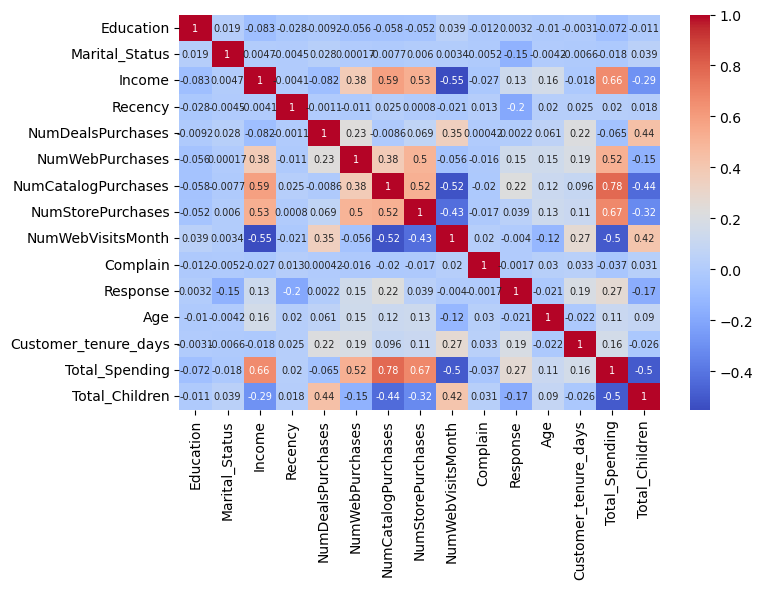

In [14]:
#correlation heatmap
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":7},
    cmap = "coolwarm"
)
plt.tight_layout()

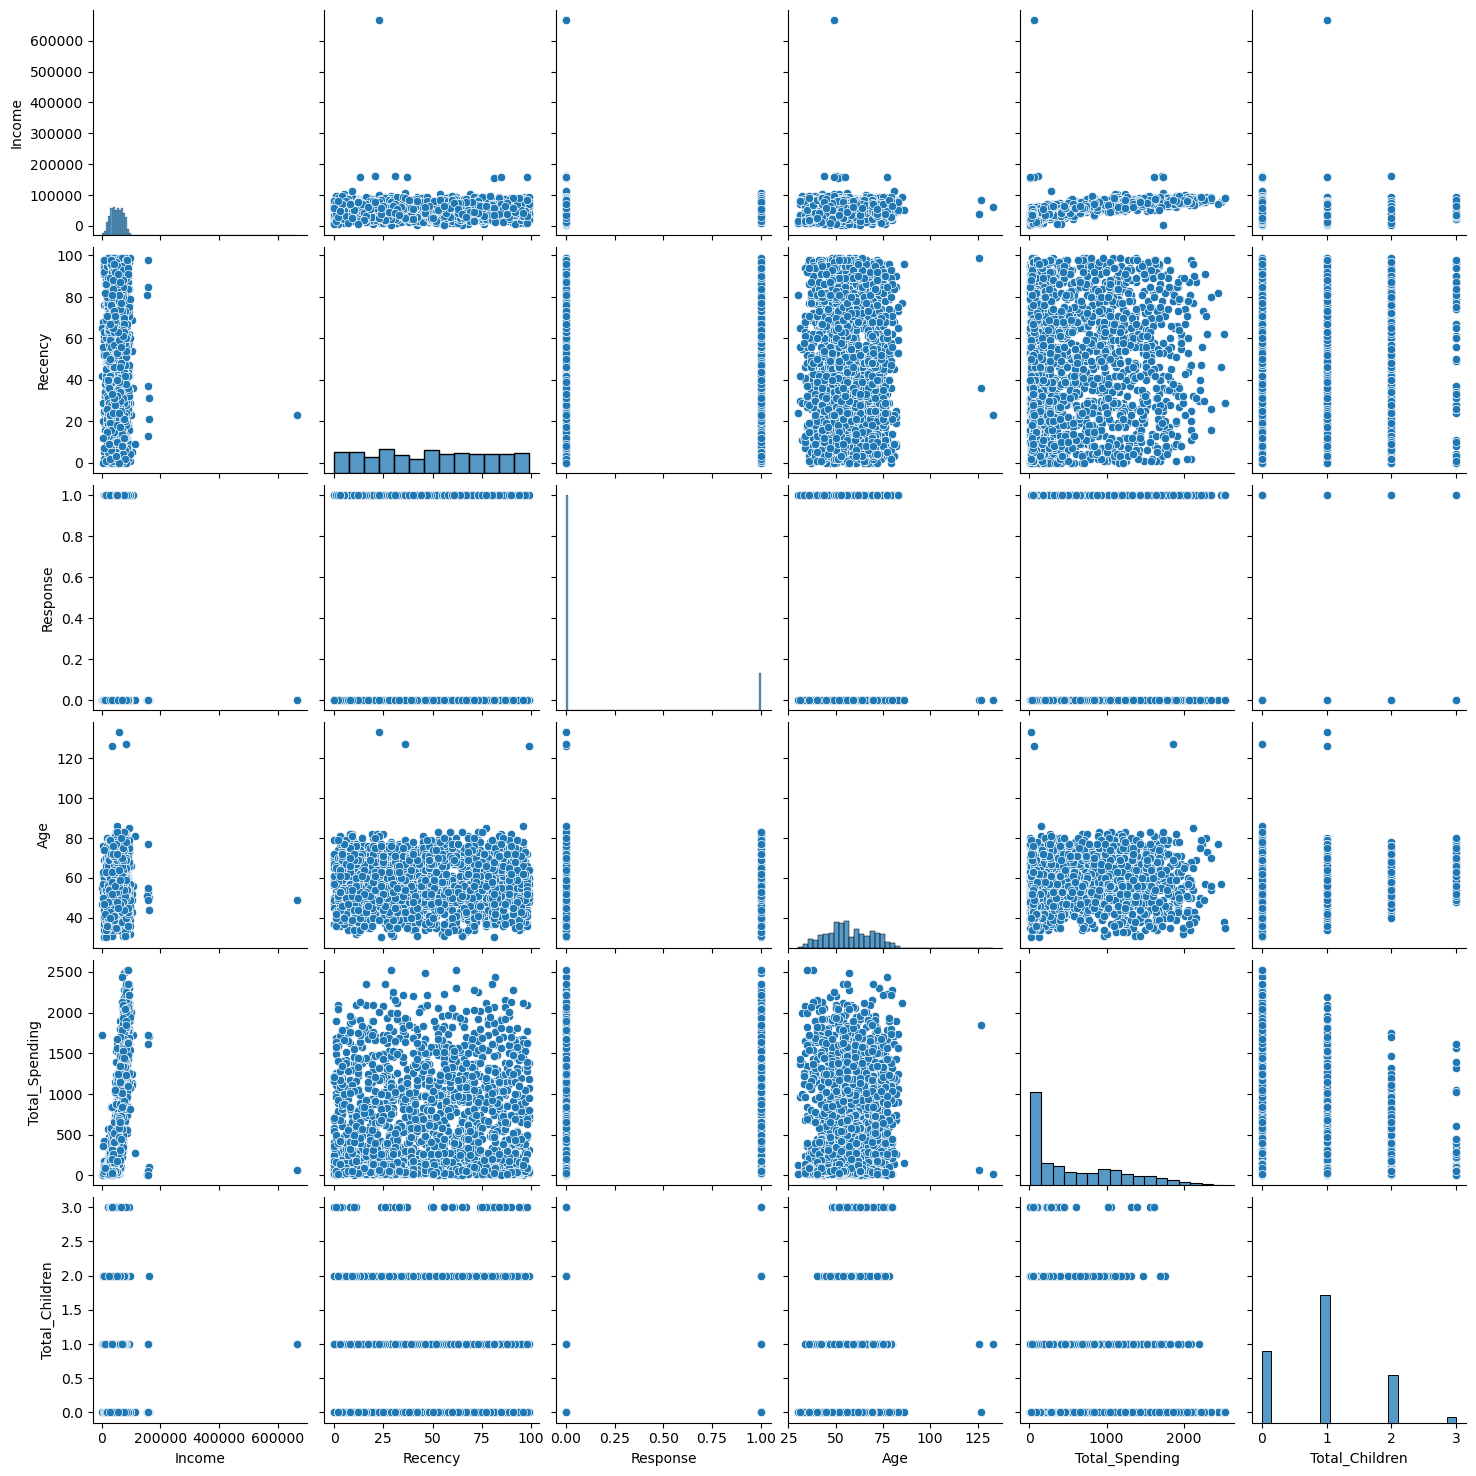

In [16]:

cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df[cols])

In [17]:
# Remove outliers

print("data size with outliers:", len(df))

df = df[ (df["Age"] < 90) ]
df = df[ (df["Income"] < 600_000) ]

print("data size without outliers:", len(df))

data size with outliers: 2240
data size without outliers: 2236


In [18]:
df.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children
0,0,0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0
1,0,0,46344.0,38,2,1,1,2,5,0,0,72,113,27,2
2,0,1,71613.0,26,1,8,2,10,4,0,0,61,312,776,0
3,0,1,26646.0,26,2,2,0,4,6,0,0,42,139,53,1
4,1,1,58293.0,94,5,5,3,6,5,0,0,45,161,422,1


In [19]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
df_scaled = scaler.fit_transform(df)

In [27]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)
pca.explained_variance_ratio_

array([0.2764765 , 0.12026703, 0.09063708])

Text(0.5, 0.92, '3d projection')

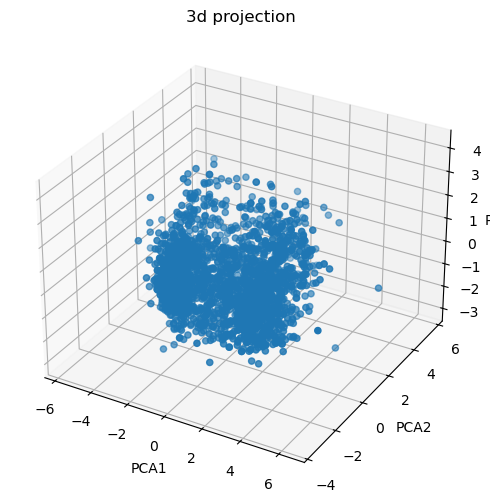

In [29]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(df_pca[:, 0], df_pca[:, 1], df_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [45]:
#choosing k value through elbow method
!pip install kneed
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state=42)
    kmeans.fit_predict(df_pca)
    wcss.append(kmeans.inertia_)

In [47]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
optimal_k

np.int64(3)

Text(0, 0.5, 'WCSS')

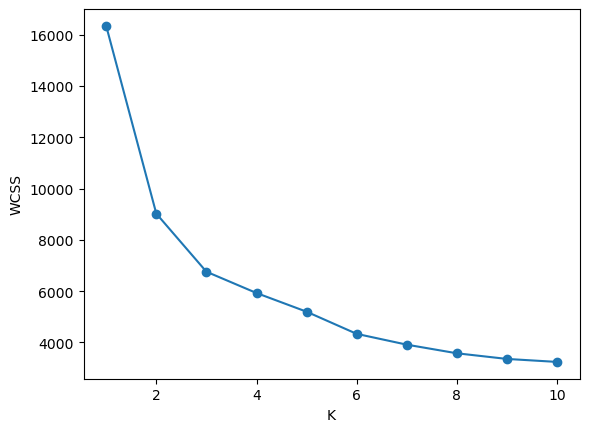

In [48]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

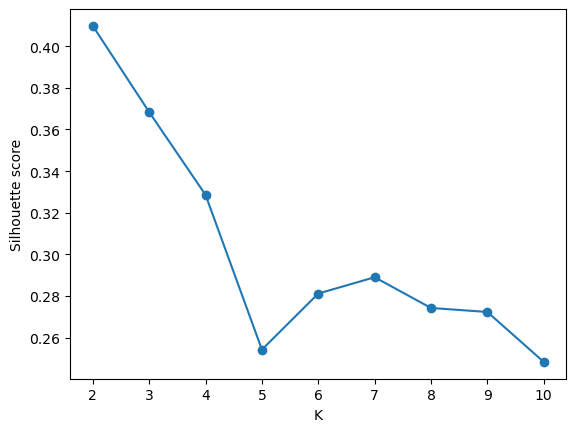

In [49]:
#silhouette score
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

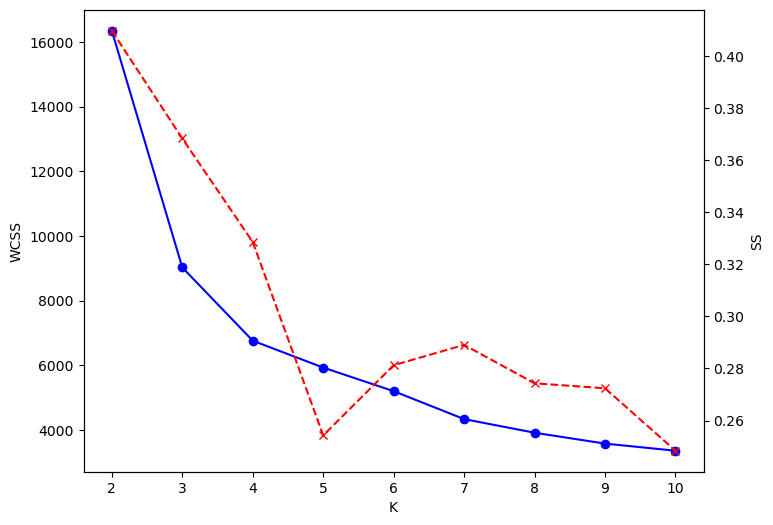

In [50]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

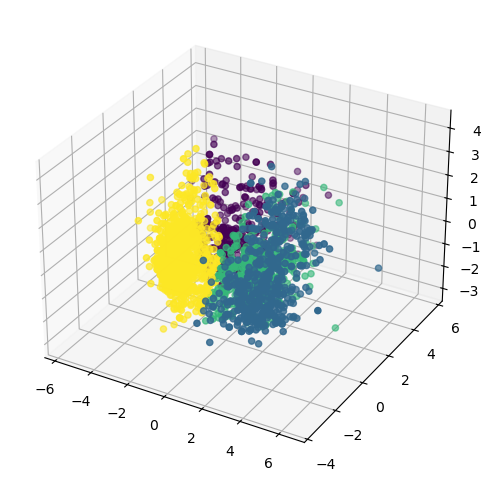

In [54]:
#kmeans
kmeans = KMeans(n_clusters=4,random_state=42)
kmeans_labels = kmeans.fit_predict(df_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_pca[:, 0], df_pca[:, 1], df_pca[:, 2], c=kmeans_labels)

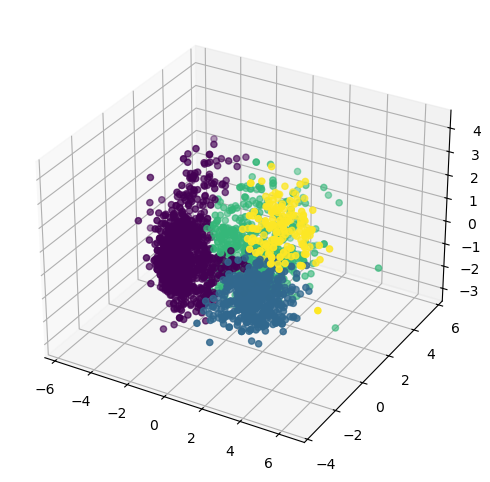

In [55]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(df_pca)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_pca[:, 0], df_pca[:, 1], df_pca[:, 2], c=labels_agg)

<Axes: xlabel='cluster', ylabel='count'>

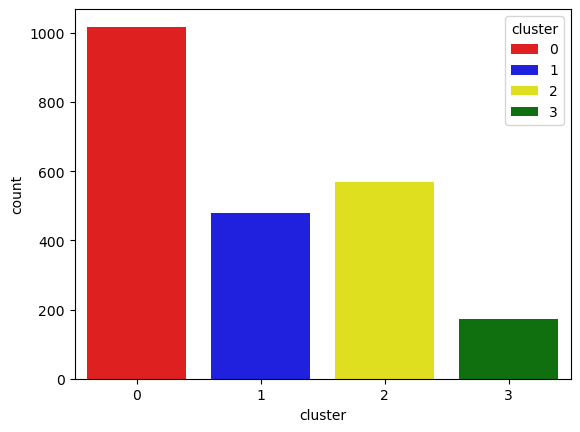

In [56]:
#characterization of clusters
df["cluster"] = labels_agg
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=df["cluster"], palette=pal, hue=df["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

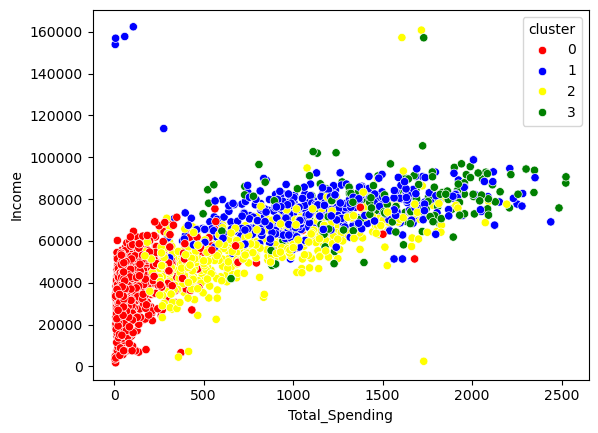

In [57]:
# Income & Spending patterns

sns.scatterplot(x=df["Total_Spending"], y=df["Income"], hue=df["cluster"], palette=pal)

In [58]:
cluster_summary = df.groupby("cluster").mean()
print(cluster_summary)

         Education  Marital_Status        Income    Recency  \
cluster                                                       
0         0.673870        0.640472  35103.619352  48.784872   
1         0.531381        0.725941  73794.447699  54.688285   
2         0.566901        0.660211  55852.789613  49.047535   
3         0.598837        0.395349  78095.523256  35.819767   

         NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  \
cluster                                                            
0                 1.899804         2.077603             0.588409   
1                 1.330544         4.870293             5.158996   
2                 4.295775         6.531690             3.204225   
3                 1.110465         5.738372             6.220930   

         NumStorePurchases  NumWebVisitsMonth  Complain  Response        Age  \
cluster                                                                        
0                 3.291749           6.328094  0.011